# Red Neuronal con Pytorch (Dataset de Regresión Multivariable)

## Preparación de librerías y datos

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import torch
import torchvision
from tqdm import tqdm
from matplotlib import pyplot
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [2]:
# Conectar Google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [35]:
# Cargar dataset
data = pd.read_csv("/content/gdrive/MyDrive/SIS420/datasets/datasets_tareas/nyc_housing_base.csv")

# Mostrar columnas del dataset
print("Columnas del dataset:\n")
print(data.columns)

# Mostrar primeras 10 filas para inspección
print("\nPrimeras 10 filas del dataset:\n")
print(data.head(10))


# =========================
# Convertir variables categóricas a numéricas
# =========================

data['borough_y'] = data['borough_y'].astype('category').cat.codes
data['bldgclass'] = data['bldgclass'].astype('category').cat.codes


# =========================
# Atributos para la regresión
# =========================

features = [
    'borough_x',
    'block',
    'lot',
    'zip_code',
    'borough_y',
    'yearbuilt',
    'lotarea',
    'bldgarea',
    'resarea',
    'comarea',
    'unitsres',
    'unitstotal',
    'numfloors',
    'latitude',
    'longitude',
    'landuse',
    'building_age',
    'bldgclass'
]


# Revisar NaN antes de limpiar
print("\nNaN antes de limpiar:")
print(data[features].isna().sum())


# =========================
# Imputación con registros similares
# =========================

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

data[features] = imputer.fit_transform(data[features])


# =========================
# Verificar que ya no haya NaN
# =========================

print("\nNaN después de limpiar:")
print(data[features].isna().sum())



# =========================
# Variables independientes
# =========================

X = data[features]

# Variable dependiente
y = np.log(data['sale_price'])


# Convertir de pandas a numpy
X = X.values
y = y.values


# Cantidad de registros
m = y.size
print("\nNúmero de registros:", m)


print("\nPrimeros 10 registros usados en la regresión:\n")
print(data[features + ['sale_price']].head(10))

Columnas del dataset:

Index(['borough_x', 'block', 'lot', 'sale_price', 'zip_code', 'borough_y',
       'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres',
       'unitstotal', 'numfloors', 'latitude', 'longitude', 'landuse',
       'bldgclass', 'building_age'],
      dtype='object')

Primeras 10 filas del dataset:

   borough_x  block  lot  sale_price  zip_code borough_y  yearbuilt  lotarea  \
0          1    400   11      280000   10009.0        MN     1900.0   2404.0   
1          1    402   36     2000000   10009.0        MN     1900.0   1919.0   
2          1    402   60     3400000   10009.0        MN     1920.0   2150.0   
3          1    404   42     4000000   10009.0        MN     1855.0   2369.0   
4          1    372   55      655000   10009.0        MN     1920.0   5298.0   
5          1    373   46      470000   10009.0        SI     1944.0   3132.0   
6          1    373   46      474000   10009.0        SI     1944.0   3132.0   
7          1    374    

In [36]:
# Normalización
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# Aplicar la función
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)

Media calculada: [ 3.07360841e+00  4.56269453e+03  6.00571736e+01  1.08664489e+04
  1.93759981e+00  1.94100758e+03  5.24402227e+04  6.27157026e+04
  5.57365394e+04  6.81812720e+03  5.17167746e+01  5.23097651e+01
  4.22493986e+00  4.07073343e+01 -7.39198322e+01  1.94319231e+00
  8.39924214e+01  1.82190830e+01]
Desviación estandar calculada: [1.28705314e+00 3.61096512e+03 1.36514576e+02 5.57706918e+02
 1.44457201e+00 2.89847817e+01 5.03196860e+05 2.71262390e+05
 2.11065694e+05 6.95223840e+04 1.73382822e+02 1.74961786e+02
 5.22784796e+00 8.21897033e-02 1.08326418e-01 1.34552676e+00
 2.89847817e+01 2.05922488e+01]


## Modelos



In [37]:
# Split train/test
from sklearn.utils import shuffle

X_norm, y = shuffle(X_norm, y, random_state=42)

split = int(m * 0.80)

X_train = X_norm[:split]
X_test = X_norm[split:]

y_train = y[:split]
y_test = y[split:]

In [38]:
# Detectar GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [39]:
# convertimos datos a tensores y copiamos en gpu
X_t = torch.from_numpy(X_train).float().to(device)
Y_t = torch.from_numpy(y_train).float().to(device)

In [40]:
# Modelo Sequential
D_in, H1, H2, H3, H4, D_out = 18, 512, 256, 128, 64, 1

model = torch.nn.Sequential(

    torch.nn.Linear(D_in, H1),
    torch.nn.BatchNorm1d(H1),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),

    torch.nn.Linear(H1, H2),
    torch.nn.BatchNorm1d(H2),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),

    torch.nn.Linear(H2, H3),
    torch.nn.BatchNorm1d(H3),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),

    torch.nn.Linear(H3, H4),
    torch.nn.BatchNorm1d(H4),
    torch.nn.ReLU(),

    torch.nn.Linear(H4, D_out),
)

# probar que el modelo recibe los datos en las dimensiones correctas
x_prueba = torch.randn(500, D_in)
outputs = model(x_prueba)
outputs.shape

torch.Size([500, 1])

In [41]:
#  Modelo custom (nn.Module)
class ModeloPersonalizado(torch.nn.Module):

    def __init__(self, D_in, H1, H2, H3, H4, D_out):
        super(ModeloPersonalizado, self).__init__()

        self.fc1 = torch.nn.Linear(D_in, H1)
        self.bn1 = torch.nn.BatchNorm1d(H1)
        self.relu1 = torch.nn.ReLU()
        self.drop1 = torch.nn.Dropout(0.2)

        self.fc2 = torch.nn.Linear(H1, H2)
        self.bn2 = torch.nn.BatchNorm1d(H2)
        self.relu2 = torch.nn.ReLU()
        self.drop2 = torch.nn.Dropout(0.2)

        self.fc3 = torch.nn.Linear(H2, H3)
        self.bn3 = torch.nn.BatchNorm1d(H3)
        self.relu3 = torch.nn.ReLU()
        self.drop3 = torch.nn.Dropout(0.2)

        self.fc4 = torch.nn.Linear(H3, H4)
        self.bn4 = torch.nn.BatchNorm1d(H4)
        self.relu4 = torch.nn.ReLU()

        self.fc5 = torch.nn.Linear(H4, D_out)


    def forward(self, x):

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.drop2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.drop3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = self.relu4(x)

        x = self.fc5(x)

        return x

## Dataset - dataloader

In [42]:
# Dataset personalizado
class DatasetPersonalizado(torch.utils.data.Dataset):
    # constructor
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float().to(device)
        self.Y = torch.from_numpy(Y).float().to(device)
    # devolvemos el número de datos en el dataset
    def __len__(self):
        return len(self.X)
    # devolvemos el elemento ix del dataset
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [43]:
# DataLoader como diccionario
dataloader = {
    'train': torch.utils.data.DataLoader(
                DatasetPersonalizado(X_train, y_train),
                batch_size=256, shuffle=True),
    'test':  torch.utils.data.DataLoader(
                DatasetPersonalizado(X_test, y_test),
                batch_size=256, shuffle=False)
}

x, y_b = next(iter(dataloader['train']))
print(x.shape, y_b.shape)

torch.Size([256, 18]) torch.Size([256])


# Entrenamiento y evaluacion

In [44]:
# Función fit
train_losses = []  # equivalente a J_history del código original

def fit(model, dataloader, epochs=400, PATH="./checkpoint.pt"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    best_loss = float("inf")
    for epoch in range(1, epochs+1):
        model.train()
        train_loss = []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y.unsqueeze(1))
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            bar.set_description(f"loss {np.mean(train_loss):.5f}")
        bar = tqdm(dataloader['test'])
        val_loss = []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y.unsqueeze(1))
                val_loss.append(loss.item())
                bar.set_description(f"val_loss {np.mean(val_loss):.5f}")
        # guardar modelo si es el mejor
        val_loss = np.mean(val_loss)
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
            print(f"Best model saved at epoch {epoch} with val_loss {val_loss:.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {val_loss:.5f}")
        # acumulamos el loss por epoch para graficar
        train_losses.append(np.mean(train_loss))
    # cargar el mejor modelo al final del entrenamiento
    model.load_state_dict(torch.load(PATH))

In [45]:
# Función evaluate
def evaluate(model, dataloader):
    model.eval()
    model.to(device)
    bar = tqdm(dataloader['test'])
    mae = []
    with torch.no_grad():
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            y_hat = model(X)
            error = torch.mean(torch.abs(y_hat.squeeze() - y)).item()
            mae.append(error)
            bar.set_description(f"mae {np.mean(mae):.5f}")

In [46]:
# Entrenar y evaluar
model = ModeloPersonalizado(D_in, H1, H2, H3, H4, D_out)
fit(model, dataloader)
evaluate(model, dataloader)

val_loss 98.92713: 100%|██████████| 27/27 [00:00<00:00, 275.37it/s]


Best model saved at epoch 1 with val_loss 98.92713
Epoch 1/400 loss 141.68421 val_loss 98.92713


val_loss 31.36332: 100%|██████████| 27/27 [00:00<00:00, 288.72it/s]


Best model saved at epoch 2 with val_loss 31.36332
Epoch 2/400 loss 62.44136 val_loss 31.36332


val_loss 3.76402: 100%|██████████| 27/27 [00:00<00:00, 262.86it/s]


...

val_loss 0.32926: 100%|██████████| 27/27 [00:00<00:00, 199.48it/s]


Epoch 399/400 loss 0.30520 val_loss 0.32926


val_loss 0.32775: 100%|██████████| 27/27 [00:00<00:00, 230.56it/s]


Epoch 400/400 loss 0.30780 val_loss 0.32775


mae 0.38259: 100%|██████████| 27/27 [00:00<00:00, 200.00it/s]


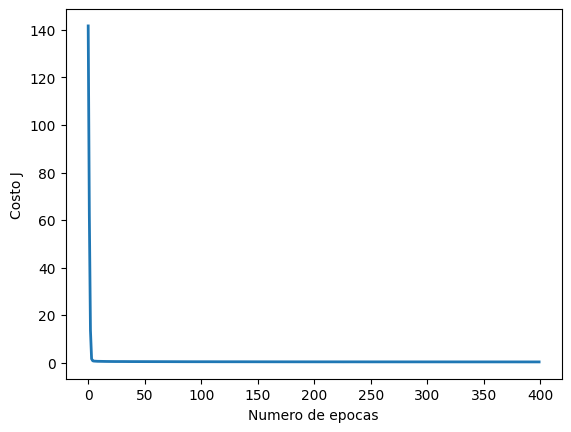

In [47]:
# Gráfica de convergencia - equivalente a J_history del código original
pyplot.plot(np.arange(len(train_losses)), train_losses, lw=2)
pyplot.xlabel('Numero de epocas')
pyplot.ylabel('Costo J')
pyplot.show()

## Guardar Modelo

In [48]:
# guardar solo pesos
PATH = './checkpoint.pt'
torch.save(model.state_dict(), PATH)

# cargar pesos
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()

# guardar modelo completo
torch.save(model, 'model.pt')

# cargar modelo completo
model = torch.load('model.pt', weights_only=False)
model.eval()

ModeloPersonalizado(
  (fc1): Linear(in_features=18, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=128, out_features=64, bias=True)
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU()
  (fc5): Linear(in_features=64, out_features=1, bias=True)
)

## Predicción nuevos datos

In [50]:
# =========================
# Nuevos datos (MISMO ORDEN que features)
# =========================

X_array = [
    3,      # borough_x
    1200,   # block
    45,     # lot
    10001,  # zip_code
    2,      # borough_y
    1990,   # yearbuilt
    2000,   # lotarea
    1500,   # bldgarea
    1200,   # resarea
    0,      # comarea
    2,      # unitsres
    2,      # unitstotal
    2,      # numfloors
    40.7,   # latitude
    -73.9,  # longitude
    1,      # landuse
    35,     # building_age
    10      # bldgclass
]

# Convertir a numpy
X_array = np.array(X_array)

# Normalizar usando mu y sigma del entrenamiento
X_array = ((X_array - mu) / sigma).astype(np.float32)

# Convertir a tensor
tensor = torch.tensor(X_array).unsqueeze(0).to(device)

# Predicción
model.eval()
with torch.no_grad():
    log_price = model(tensor).item()
    price = np.exp(log_price)

print("Precio predicho:", price)

Precio predicho: 670134.4293487804


In [51]:
# TorchScript (tracing)
x = torch.randn(1, D_in)
traced_model = torch.jit.trace(model.cpu(), x)
traced_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

In [52]:
scripted_model = torch.jit.script(model.cpu())
scripted_model.save('model.zip')

loaded_model = torch.jit.load('model.zip')

In [54]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.3 MB/s eta 0:00:00


In [55]:
x = torch.randn(1, D_in)

torch.onnx.export(model.cpu(),
                  x,
                  "model.onnx",
                  export_params=True,
                  opset_version=10,
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input':  {0: 'batch_size'},
                                'output': {0: 'batch_size'}})

/tmp/ipykernel_904/2817503493.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model.cpu(),
W0402 02:43:52.769000 904 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 10 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0402 02:43:53.699000 904 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int'

[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ModeloPersonalizado([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 4 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,18]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,1]>
            ),
            initializers=(
                %"fc1.bias"<FLOAT,[512]>{Tensor(...)},
                %"fc2.bias"<FLOAT,[256]>{Tensor(...)},
                %"fc3.bias"<FLOAT,[128]>{Tensor(...)},
                %"fc4.bias"<FLOAT,[64]>{Tensor(...)},
                %"fc5.weight"<FLOAT,[1,64]>{TorchTensor(...)},
                %"fc5.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([0.6406], requires_grad=True), name='fc5.bias')},
                %"fc1.weight"<FLOAT,[512,18]>{Tensor(...)},
                %"fc2.weight"<F

## Test

In [61]:
# predicciones del modelo PyTorch sobre el 20% de test
model.to(device)
model.eval()
with torch.no_grad():
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_pred_pytorch = model(X_test_t).cpu().numpy().flatten()

# Convertir de log a precio real
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_pytorch)

print("Primeras 10 predicciones vs valores reales:")
print(f"{'Real($)':>15}  {'Predicho($)':>15}  {'Diferencia($)':>15}")

for real, pred in zip(y_test_real[:10], y_pred_real[:10]):
    print(f"{real:>15,.0f}  {pred:>15,.0f}  {abs(real - pred):>15,.0f}")

Primeras 10 predicciones vs valores reales:
        Real($)      Predicho($)    Diferencia($)
        615,000        1,197,859          582,859
        590,000          649,355           59,355
        980,000          681,434          298,566
        910,000          723,260          186,740
        600,000          596,428            3,571
      1,500,000          867,889          632,111
      1,250,000        1,032,131          217,869
      1,400,000          835,510          564,490
        370,000          328,617           41,383
      5,600,000        1,096,037        4,503,963


In [63]:
mae = np.mean(np.abs(y_pred_real - y_test_real))
print(f"MAE: ${mae:,.0f}")
# porcentaje de aciertos dentro del ±20% del precio real
margen = 0.20
aciertos = np.mean(np.abs(y_pred_pytorch - y_test) / y_test <= margen) * 100
print(f"Aciertos (±20%): {aciertos:.2f}%")

MAE: $451,725
Aciertos (±20%): 99.48%


In [68]:
# =========================
# Accuracy de regresión
# =========================

# Convertir de log a precio real
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_pytorch)

print("\nAccuracy del modelo según margen de error:\n")

margenes = [0.05, 0.10, 0.20, 0.30, 0.50]

for m in margenes:
    accuracy = np.mean(np.abs(y_pred_real - y_test_real) / y_test_real <= m) * 100
    print(f"Aciertos dentro de ±{int(m*100)}%: {accuracy:.2f}%")


Accuracy del modelo según margen de error:

Aciertos dentro de ±5%: 10.90%
Aciertos dentro de ±10%: 21.60%
Aciertos dentro de ±20%: 41.70%
Aciertos dentro de ±30%: 57.78%
Aciertos dentro de ±50%: 76.50%


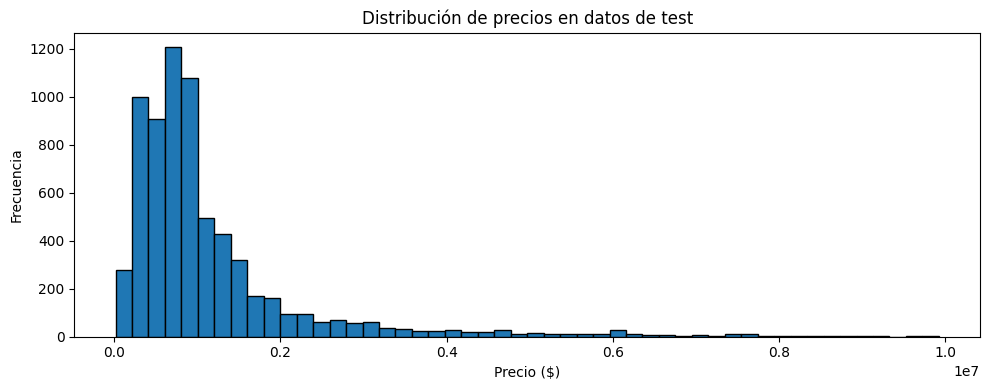

Precio mínimo:  $15,210
Precio máximo:  $9,924,796
Precio promedio: $1,165,521
Precio mediana:  $815,000


In [66]:
# Convertir de log(precio) a precio real
y_test_real = np.exp(y_test)

pyplot.figure(figsize=(10, 4))
pyplot.hist(y_test_real, bins=50, edgecolor='black')
pyplot.xlabel('Precio ($)')
pyplot.ylabel('Frecuencia')
pyplot.title('Distribución de precios en datos de test')
pyplot.tight_layout()
pyplot.show()

print(f"Precio mínimo:  ${y_test_real.min():,.0f}")
print(f"Precio máximo:  ${y_test_real.max():,.0f}")
print(f"Precio promedio: ${y_test_real.mean():,.0f}")
print(f"Precio mediana:  ${np.median(y_test_real):,.0f}")

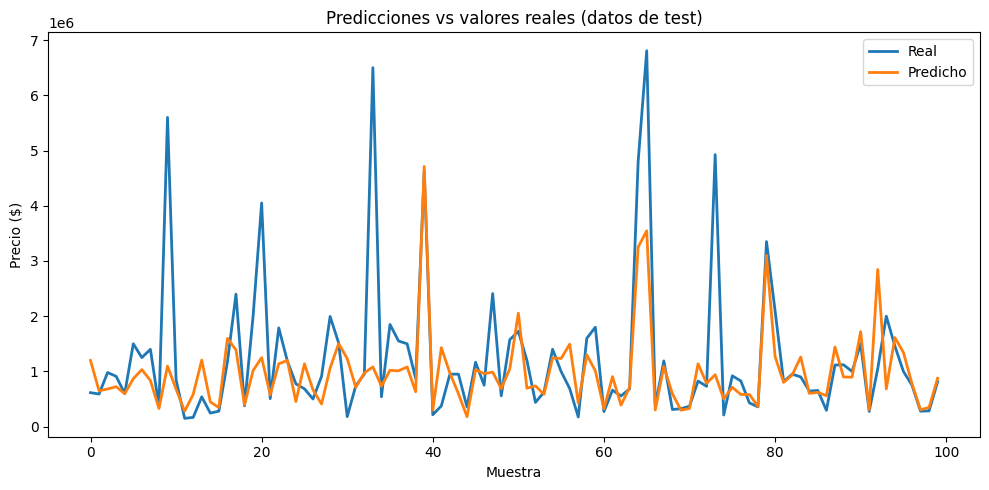

In [69]:
# Convertir de log(precio) a precio real
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_pytorch)

pyplot.figure(figsize=(10, 5))
pyplot.plot(y_test_real[:100], label='Real', lw=2)
pyplot.plot(y_pred_real[:100], label='Predicho', lw=2)

pyplot.xlabel('Muestra')
pyplot.ylabel('Precio ($)')
pyplot.title('Predicciones vs valores reales (datos de test)')
pyplot.legend()
pyplot.tight_layout()
pyplot.show()